In [1]:
%load_ext autoreload
%autoreload 2

from spyglass.decoding.v1.clusterless import UnitWaveformFeaturesGroup, UnitWaveformFeatures
import matplotlib.pyplot as plt
from pynwb import TimeSeries
from pynwb import NWBHDF5IO
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
os.chdir("..")

from c3po.analysis.analysis import bootstrap_traces

[2026-05-21 09:29:48,621][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


# Load Data

In [2]:
key = {
    "nwb_file_name": "Wallie20220912_.nwb",
    "waveform_features_group_name": "10_lineartrack",
}

In [3]:
# Position
# load position data
from spyglass.common import PositionIntervalMap
from spyglass.decoding.v1.core import PositionGroup
from spyglass.position.position_merge import PositionOutput
from spyglass.linearization.v1 import LinearizedPositionV1
from scipy.ndimage import gaussian_filter1d

epoch_key = {
    "nwb_file_name": key["nwb_file_name"],
    "interval_list_name": key["waveform_features_group_name"],
}
pos_interval = (PositionIntervalMap() & epoch_key).fetch1("position_interval_name")
pos_key = {
    "nwb_file_name": key["nwb_file_name"],
    "interval_list_name": pos_interval,
    "trodes_pos_params_name": "single_led_upsampled",
}
pos_merge_id = (PositionOutput.TrodesPosV1() & pos_key).fetch("merge_id")
pos_merge_key = {"pos_merge_id": pos_merge_id[0]}


pos_df = (LinearizedPositionV1() & pos_merge_key).fetch1_dataframe()
pos_times = pos_df.index.values  # - first_mark_time
pos = pos_df.linear_position.values
vel = np.diff(pos_df.linear_position.values)
vel = np.concatenate([vel, [vel[-1]]])
vel = gaussian_filter1d(vel, 11, axis=0, mode="nearest")

# pos_ind = np.digitize(mark_times / 1000, pos_times - first_mark_time) - 1
# mark_pos = pos[pos_ind]
# mark_vel = vel[pos_ind]

# Define position-based intervals
all_running = (np.abs(vel * 500) > 10).astype(int)
right_running = ((vel * 500) > 10).astype(int)
left_running = ((vel * 500) < -10).astype(int)

st = np.where(np.diff(all_running) == 1)[0]
en = np.where(np.diff(all_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
all_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)
st = np.where(np.diff(left_running) == 1)[0]
en = np.where(np.diff(left_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
left_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)

st = np.where(np.diff(right_running) == 1)[0]
en = np.where(np.diff(right_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
right_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)

# LFP from spyglass.lfp.analysis.v1 import LFPBandV1
from spyglass.lfp import LFPOutput

ref_ind = 12  # hardcoded for dataset Wallie20220912_.nwb
lfp_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
}

exclude = (
    (LFPOutput.LFPV1() & {"lfp_electrode_group_name": "tetrode_samples"})
    .proj(lfp_merge_id="merge_id")
    .fetch("lfp_merge_id", as_dict=True)
)


# Theta band
theta_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Theta 5-11 Hz",
    # "filter_name": "Fast Gamma 65-100 Hz",
    # "filter_name": "Slow Gamma 25-55 Hz",
}
from spyglass.lfp.analysis.v1 import LFPBandV1

query = (LFPBandV1() & theta_key) - exclude

theta_band_obj = query.fetch_nwb()[0]["lfp_band"]
phase_df = query.compute_signal_phase([ref_ind])
power_df = query.compute_signal_power([ref_ind])
phase_df["phase"] = phase_df.values
phase_df["power"] = power_df.values

# Fast Gamma band
fast_gamma_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Fast Gamma 65-100 Hz",
    # "filter_name": "Slow Gamma 25-55 Hz",
}
query = (LFPBandV1() & fast_gamma_key) - exclude
band_obj = query.fetch_nwb()[0]["lfp_band"]
fg_phase_df = query.compute_signal_phase([ref_ind])
fg_power_df = query.compute_signal_power([ref_ind])
fg_phase_df["phase"] = fg_phase_df.values
fg_phase_df["power"] = fg_power_df.values

# Slow Gamma band
slow_gamma_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Slow Gamma 25-55 Hz",
}
query = (LFPBandV1() & slow_gamma_key) - exclude
band_obj = query.fetch_nwb()[0]["lfp_band"]
sg_phase_df = query.compute_signal_phase([ref_ind])
sg_power_df = query.compute_signal_power([ref_ind])
sg_phase_df["phase"] = sg_phase_df.values
sg_phase_df["power"] = sg_power_df.values

# Ripple band
ripple_band_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    # "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Ripple 150-250 Hz",
}

query = (
    LFPBandV1
    & ripple_band_key
    & f"target_interval_list_name LIKE '%{pos_key['interval_list_name']}%'"
)
ripple_band_obj = query.fetch_nwb()[0]["lfp_band"]

from spyglass.lfp.v1 import LFPV1

lfp_query = (LFPV1 & lfp_key) & dict(lfp_electrode_group_name="tetrode_sample_Wallie")
lfp_df = lfp_query.fetch1_dataframe()
lfp_df = lfp_df[ref_ind]

# spikes

from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

spikes_key = {
    "nwb_file_name": key["nwb_file_name"],
    "sorted_spikes_group_name": key["waveform_features_group_name"],
}
SortedSpikesGroup() & spikes_key
spikes_list, unit_ids = (SortedSpikesGroup() & spikes_key).fetch_spike_data(
    spikes_key, return_unit_ids=True
)

# ripples
from spyglass.ripple.v1 import RippleTimesV1, RippleLFPSelection

ripple_df = (
    RippleTimesV1()
    & key
    & f"target_interval_list_name LIKE '%{pos_key['interval_list_name']}%'"
).fetch1_dataframe()

ripple_intervals = ripple_df[["start_time", "end_time"]].values

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [4]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1

decode_query = (
    ClusterlessDecodingV1() & key & {"encoding_interval": "pos 9 valid times"}
)

results = decode_query.fetch_results()
posterior = results.causal_posterior.unstack("state_bins").sum("state")[0]
decode_pos = posterior.idxmax("position").values
decode_time = results.time.values

/home/sambray/.local/lib/python3.10/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/home/sambray/.local/lib/python3.10/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionalit

# Load model

In [5]:
import os

# if not "src" in os.listdir():
#     os.chdir("..")
os.chdir("/home/sambray/Documents/c3po/")

from src.c3po.tables.dev_tables import C3POStorage

model_name = "rat_hpc_lineartrack_16d"
model_name = "rat_hpc_lineartrack_c20z32"
model_name = "rat_hpc_lineartrack_c20z20_model2"
# model_name = "rat_hpc_lineartrack_c20z20_model2_trainRuns"
model_name = "rat_hpc_lineartrack_c20z20_model2_trainRuns_onlySmallNegSamples"
model_name = "rat_hpc_lineartrack_c20z20_model3"
# model_name = "rat_hpc_lineartrack_c8z20_model3"

model_key = {"model_name": model_name}
analysis = (C3POStorage & model_key).fetch_analysis_object()

analysis.load_embedding(
    f"/stelmo/sam/c3po_results/{model_key['model_name']}_embedding.npz"
)

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)

analysis.fit_context_pca()
analysis.embed_context_pca()
# analysis_all = analysis.copy()
# analysis_running = analysis.copy()
# analysis_ripples = analysis.copy()

# analysis_all.fit_context_pca()
# analysis_running.fit_context_pca(fit_intervals=all_running_intervals)
# analysis_ripples.fit_context_pca(fit_intervals=ripple_intervals)

# # # Just showing how to access the variables
# # t = analysis.t
# # z = analysis.z
# # c = analysis.c
# # c_pca = analysis.c_pca
# # t_interp = analysis.t_interp
# # c_interp = analysis.c_interp
# # c_pca_interp = analysis.c_pca_interp
# latent_dim, context_dim = analysis.latent_dim, analysis.context_dim

# from src.c3po.analysis.analysis import figure_directory
# from pathlib import Path

# figure_directory = Path(figure_directory)
# figure_folder = figure_directory / "Fig4" / model_name
# os.makedirs(figure_folder, exist_ok=True)
# plt.rcParams["svg.fonttype"] = "none"

x shape (1, 5)


# Decoder

In [6]:
t_feature = pos_df.index.values
feature = pos_df.linear_position.values[:, None]


# analysis.initialize_decoder(
#     "discretized_regression",
#     n_bins=100,
#     max_iter=1000,
#     balance_groups=True,
#     multidim=False,
# )

# analysis.initialize_decoder(
#     "knn",
#     n_neighbors=30,
#     weights="distance",
# )


# fit_intervals = all_running_intervals

# fit_intervals = [x for x in all_running_intervals if x[0] > pred_interval[1]]

# analysis.fit_decoder(
#     feature,
#     t_feature,
#     intervals=fit_intervals,
#     pca=True,
#     # decode_dim=slice(1, 2),
#     interpolate=True,
#     # interpolate=True,
#     # smooth_context=30,
# )

In [ ]:
t_feature = pos_df.index.values
feature = pos_df.linear_position.values[:, None]

analysis.initialize_decoder(
    "knn",
    n_neighbors=30,
    weights="distance",
)
analysis.initialize_decoder(
    "discretized_regression",
    n_bins=70,
    max_iter=100,
    balance_groups=True,
    multidim=False,
    predict_method="weighted",
    # solver = "newton-cholesky",
    n_jobs=4,
)

t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
    feature,
    t_feature,
    # intervals=all_running_intervals,
    pca=False,
    # decode_dim=1,
    interpolate=False,
    smooth_context=5,
)
t_pred = np.concatenate(t_pred_list)
feature_pred = np.concatenate(feature_pred_list)

# hd_t_pred = t_pred
# hd_pred = feature_pred[:, 0]

Cross-validating decoder:   0%|          | 0/5 [00:00<?, ?it/s]

0.23100387172934939 135.5751369546939
(486883, 1) (486883, 20)
0.23100387172934939 135.5751369546939


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sambray/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Cross-validating decoder:  20%|██        | 1/5 [00:54<03:39, 54.90s/it]

0.0 135.82341960824513
(486127, 1) (486127, 20)
0.0 135.82341960824513


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sambray/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Cross-validating decoder:  40%|████      | 2/5 [01:48<02:41, 53.96s/it]

0.0 135.82341960824513
(486128, 1) (486128, 20)
0.0 135.82341960824513


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sambray/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Cross-validating decoder:  60%|██████    | 3/5 [02:42<01:47, 53.91s/it]

0.0 135.82341960824513
(486127, 1) (486127, 20)
0.0 135.82341960824513


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sambray/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Cross-validating decoder:  80%|████████  | 4/5 [03:36<00:54, 54.08s/it]

0.0 135.82341960824513
(504027, 1) (504027, 20)
0.0 135.82341960824513


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sambray/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Cross-validating decoder: 100%|██████████| 5/5 [04:28<00:00, 53.77s/it]


In [8]:
analysis._decoder_kwargs
analysis.decoder_model.model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: np.float64(0....3313137357074), 1: np.float64(0....9926991900747), 2: np.float64(0.4366681105431863), 3: np.float64(1.000369150160759), ...}"
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


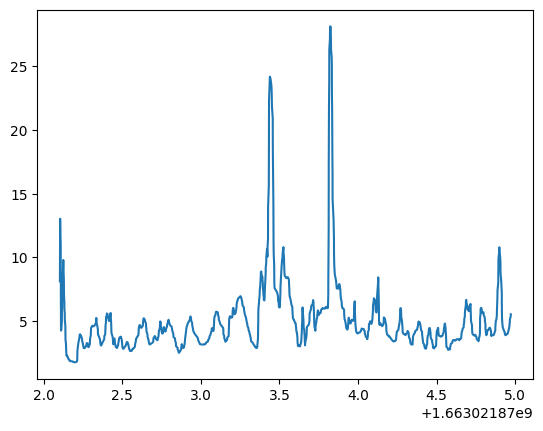

In [18]:
st = 200000
ind = slice(st, st + 15000)

st = 207000
ind = slice(st, st + 2000)
plt.plot(t_pred[ind], feature_pred[ind])

In [19]:
i_pred = 5
interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
pred_interval = interval[i_pred]

ind_pred = np.logical_and(t_pred >= pred_interval[0], t_pred <= pred_interval[1])
pos_pred = feature_pred[ind_pred]

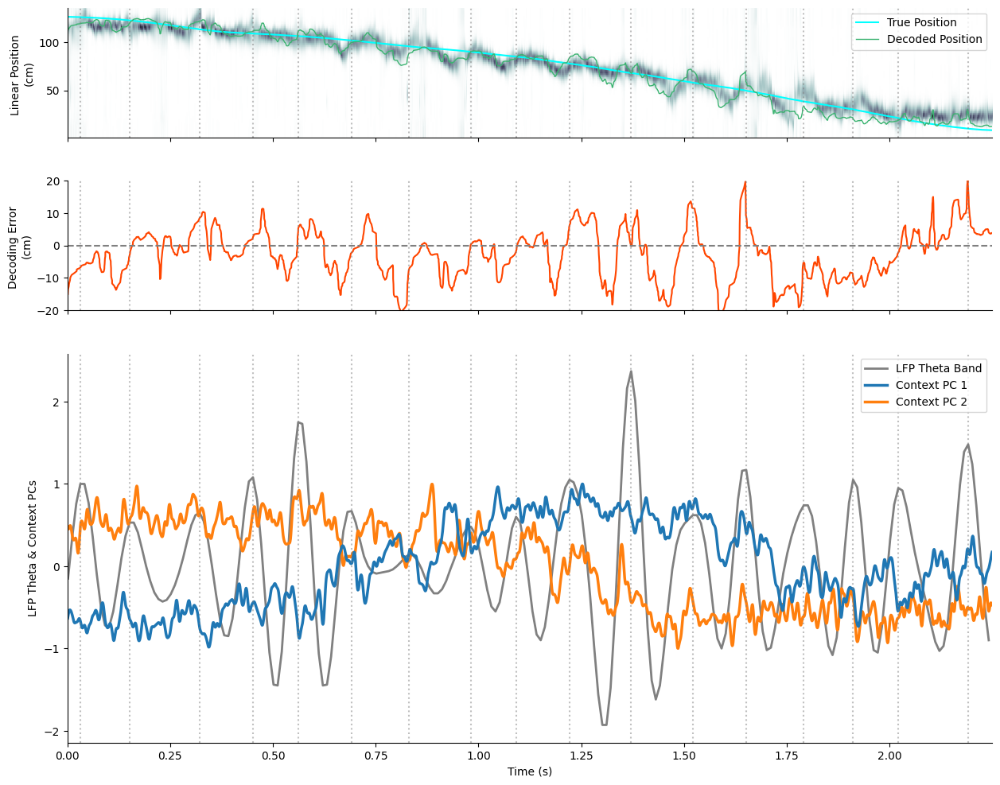

In [ ]:
# analysis = analysis_all

interval = pred_interval
st = interval[0]
en = interval[1]
pc_inds = [0, 1]
smooth_width = 3

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 1, 3],
    # figsize=(7, 6),
    figsize=(15, 12),
)
t_theta = theta_band_obj.timestamps
ind_theta = np.logical_and(
    t_theta >= st,
    t_theta <= en,
)

t_lfp = t_theta[ind_theta] - st
lfp_plot = theta_band_obj.data[ind_theta][:, ref_ind] / 100
plt.plot(
    t_theta[ind_theta] - st,
    theta_band_obj.data[ind_theta][:, ref_ind] / 100,
    c="grey",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(2):
    plt.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"Context PC {j+1}",
        lw=2.5,
    )
    # break


ind_eric = np.logical_and(
    results.time >= st,
    results.time <= en,
)
ax[0].imshow(
    posterior[ind_eric].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, results.position.min(), results.position.max()],
    zorder=-3,
)

pos_ind = np.logical_and(
    pos_df.index >= st,
    pos_df.index <= en,
)
t_pos = pos_df.index[pos_ind] - st
pos_plot = pos_df.linear_position[pos_ind]
ax[0].plot(
    t_pos,
    pos_plot,
    c="cyan",
    # s=5,
    zorder=-2,
    label="True Position",
)

ind_pred = np.logical_and(t_pred >= pred_interval[0], t_pred <= pred_interval[1])
pos_pred = feature_pred[ind_pred]
ax[0].plot(
    t_pred[ind_pred] - st,
    pos_pred,
    c="mediumseagreen",
    lw=1,
    alpha=1,
    label="Decoded Position",
    zorder=-1,
)

pos_upsampled = np.interp(
    t_pred[ind_pred] - st,
    t_pos,
    pos_plot,
)
ax[1].plot(t_pred[ind_pred] - st, pos_pred[:, 0] - pos_upsampled, color="orangered")
ax[1].axhline(0, ls="--", c="grey")
ax[1].set_ylim(-20, 20)

ax[-1].legend(loc="upper right")
ax[0].legend(loc="upper right")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[-1].set_ylabel("LFP Theta & Context PCs")
ax[1].set_ylabel("Decoding Error \n(cm)")

d_lfp = np.diff(lfp_plot)
upward = (d_lfp > 0).astype(int)
peaks = np.where(np.diff(upward) == -1)[0] + 1
peaks = t_lfp[peaks]
for a in ax:
    for p in peaks:
        if p >= 0 and p <= (en - st):
            a.axvline(p, color="grey", ls=":", alpha=0.5)

# fig.savefig(
#     figure_folder / f"example_decode_and_precessions_traces.svg",
# )

In [25]:
results.position.min(), results.position.max()

(<xarray.DataArray 'position' ()> Size: 8B
 array(0.99197367),
 <xarray.DataArray 'position' ()> Size: 8B
 array(135.90039281))

# Ripple

In [21]:
i = 4
t_rng = -0.25, 0.35

# i = 7
# t_rng = -0.25, 0.35

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[0] + t_rng[1]

# pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
# t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
ind_pred = np.logical_and(t_pred >= st, t_pred <= en)
pos_pred = feature_pred[ind_pred]

# plt.plot(t_pred[ind_pred] - st, pos_pred[ind_pred], c="mediumseagreen", label="Decoded Position")
# plt.plot(pred_t - st, pos_pred, c="mediumseagreen", label="Decoded Position")

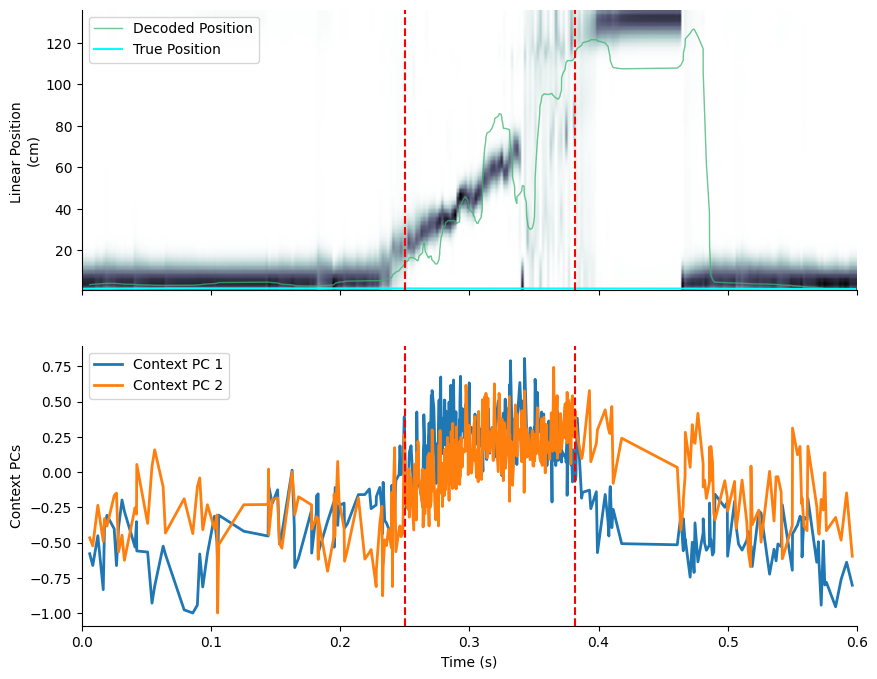

In [ ]:
pc_inds = [0, 1]

fig, ax = plt.subplots(
    nrows=2,
    sharex=True,
    height_ratios=[1, 1],
    figsize=(10, 8),
)

t_ripple = ripple_band_obj.timestamps
ind_ripple = np.logical_and(
    t_ripple >= st,
    t_ripple <= en,
)
# ax[0].plot(
#     t_ripple[ind_ripple] - st,
#     ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
#     c="k",
#     lw=2,
#     zorder=-10,
#     label="LFP Theta Band",
# )
ax[0].plot(
    t_pred[ind_pred] - st,
    pos_pred,
    c="mediumseagreen",
    label="Decoded Position",
    lw=1,
    alpha=0.75,
)


pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st,
    pos_t <= en,
)
ax[0].plot(
    pos_t[ind_pos] - st,
    pos_df.linear_position[ind_pos],
    c="cyan",
    # s=10,
    label="True Position",
)


# ind_context = np.logical_and(
#     analysis.t_interp >= st,
#     analysis.t_interp <= en,
# )
# c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
# if len(c_plot.shape) == 1:
#     c_plot = c_plot[:, None]
# c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

ind_context = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)
c_plot = analysis.c_pca[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]


c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
    )


for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[1].set_ylabel("Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])

# for t_ in interval:
#     ax[1].axvline(interval[0] - st, color="red", ls="--")

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")
    for r in np.ravel(ripple):
        if r >= st and r <= en:
            for a in ax:
                a.axvline(r - st, color="r", ls="--")


ind_decode = np.logical_and(
    decode_time >= st,
    decode_time <= en,
)
# ax[0].plot(
#     decode_time[ind_decode] - st,
#     decode_pos[ind_decode],
#     c="orange",
#     label="Eric's Clusterless Decoding",
# )

ax[0].imshow(
    posterior[ind_decode].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, results.position.min(), results.position.max()],
    zorder=-10,
)

ax[0].legend(loc="upper left")
ax[1].legend(loc="upper left")

# fig.savefig(
#     figure_folder / f"example_ripple_decode_and_model_comparison.svg",
# )

/tmp/ipykernel_3783385/2011186066.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


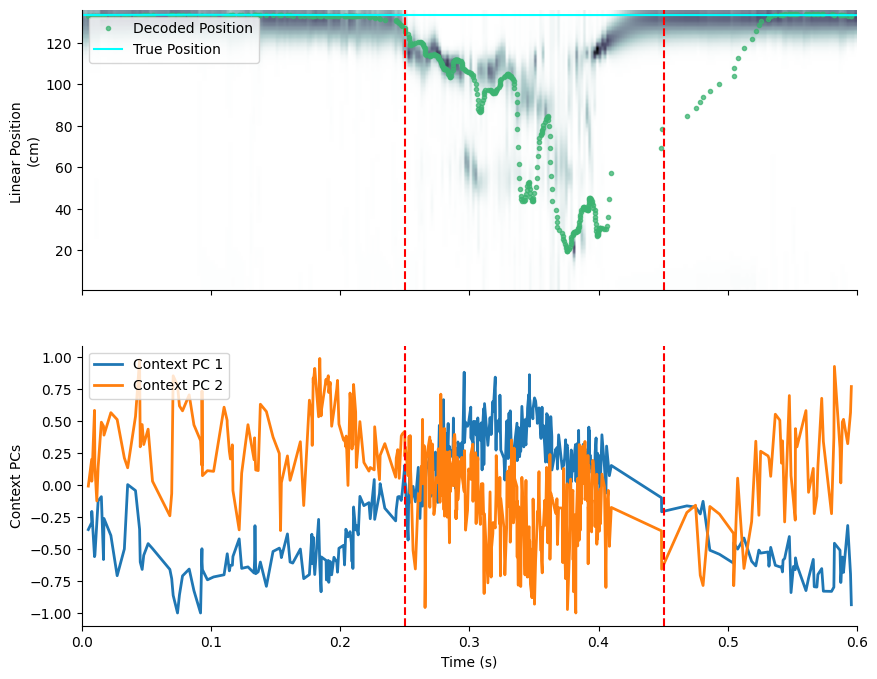

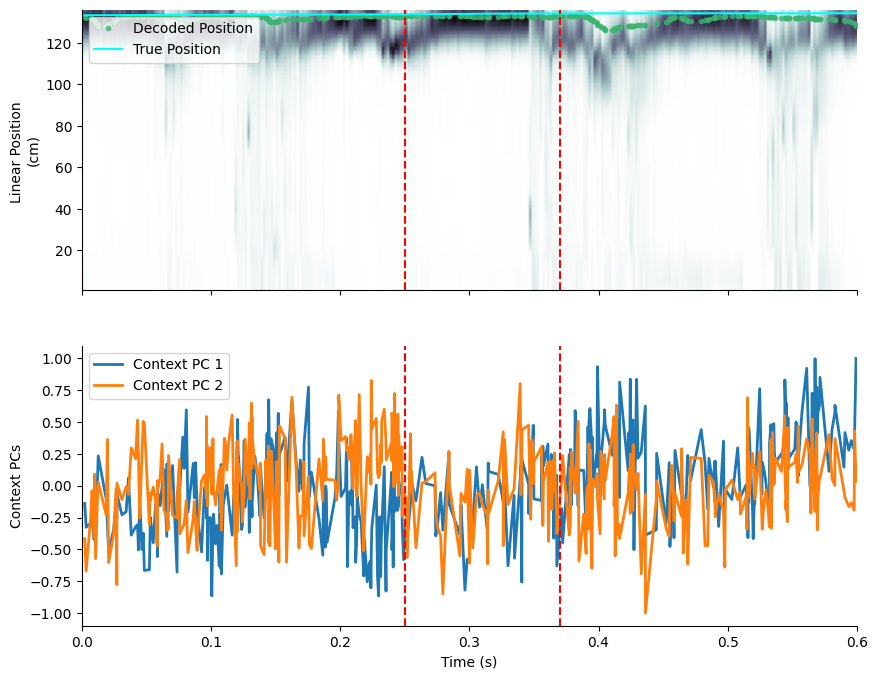

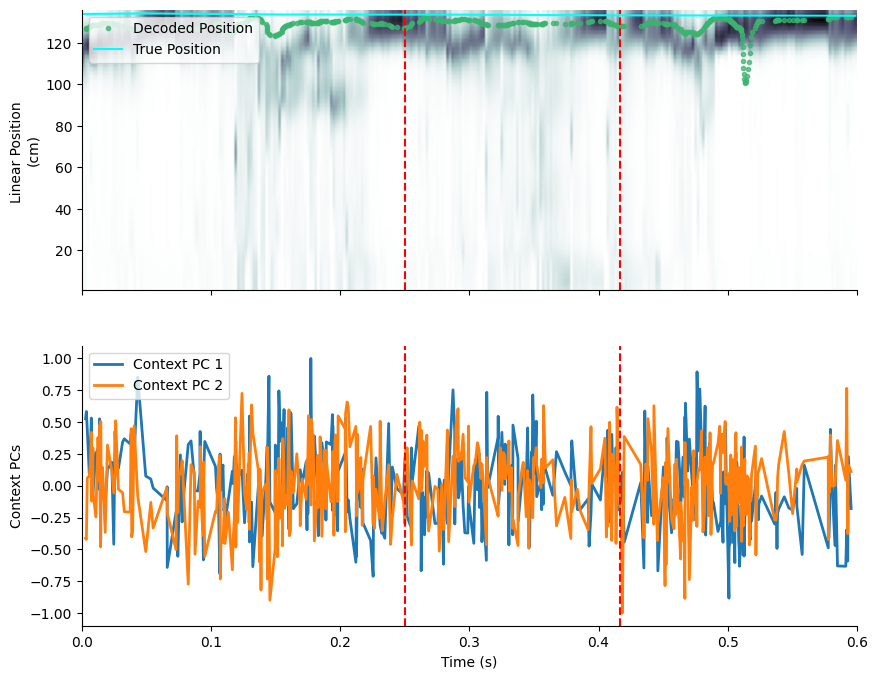

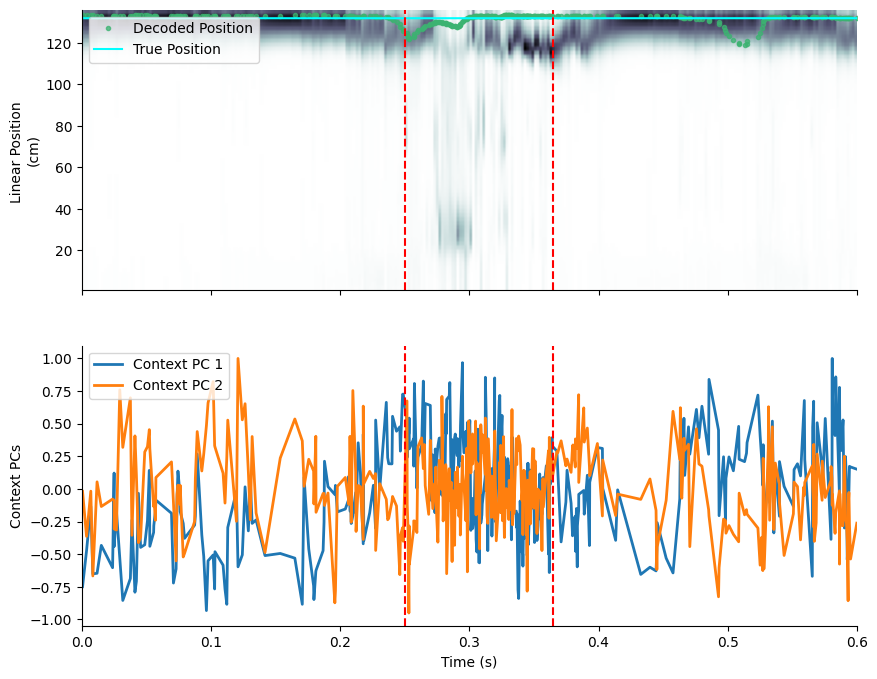

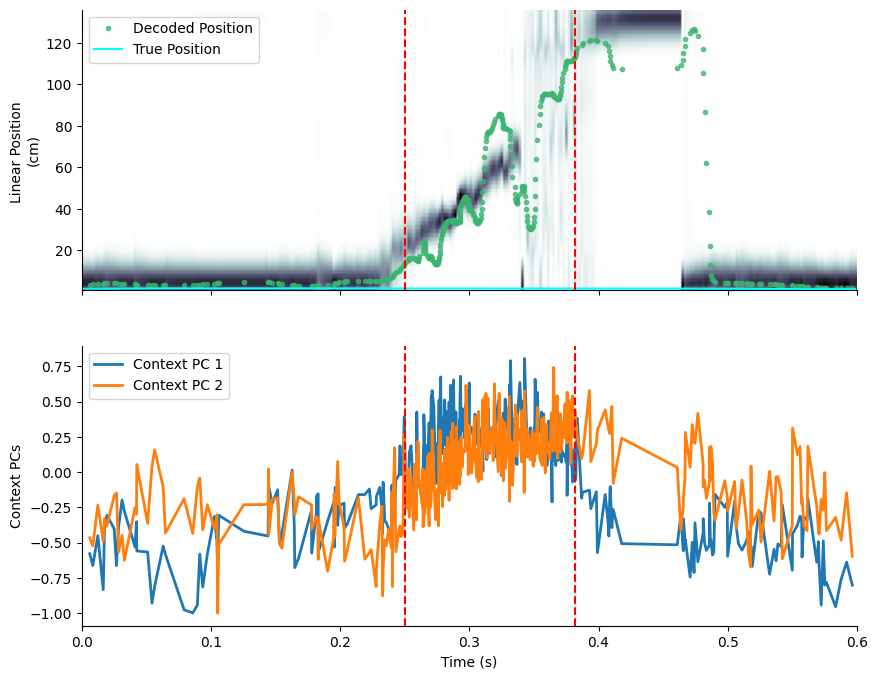

...

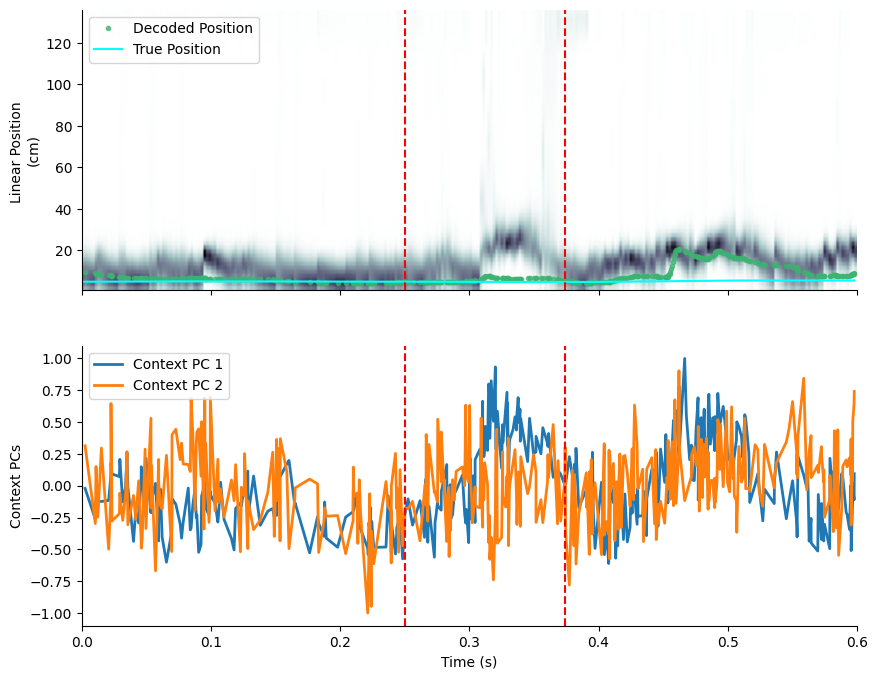

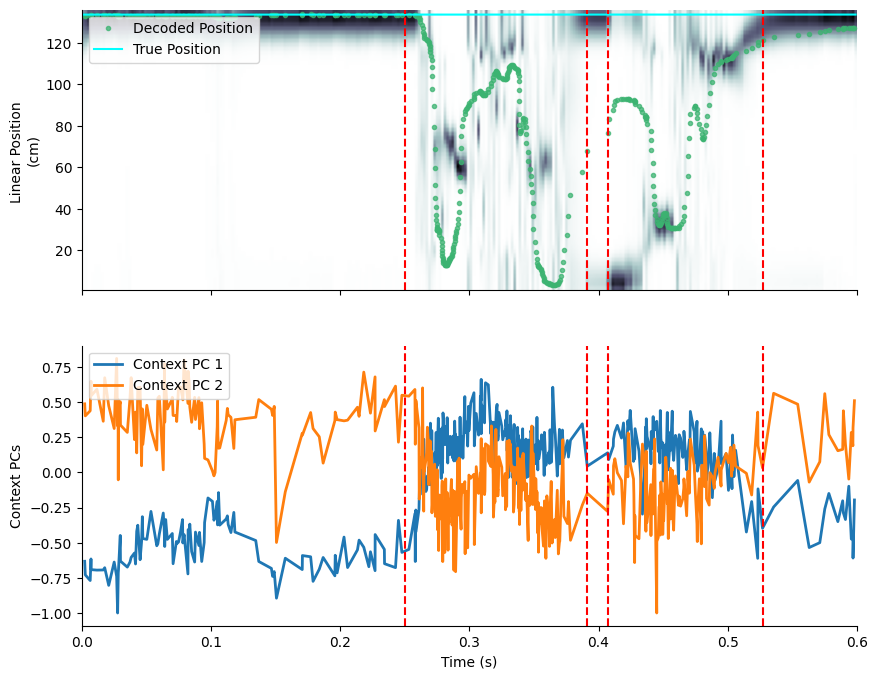

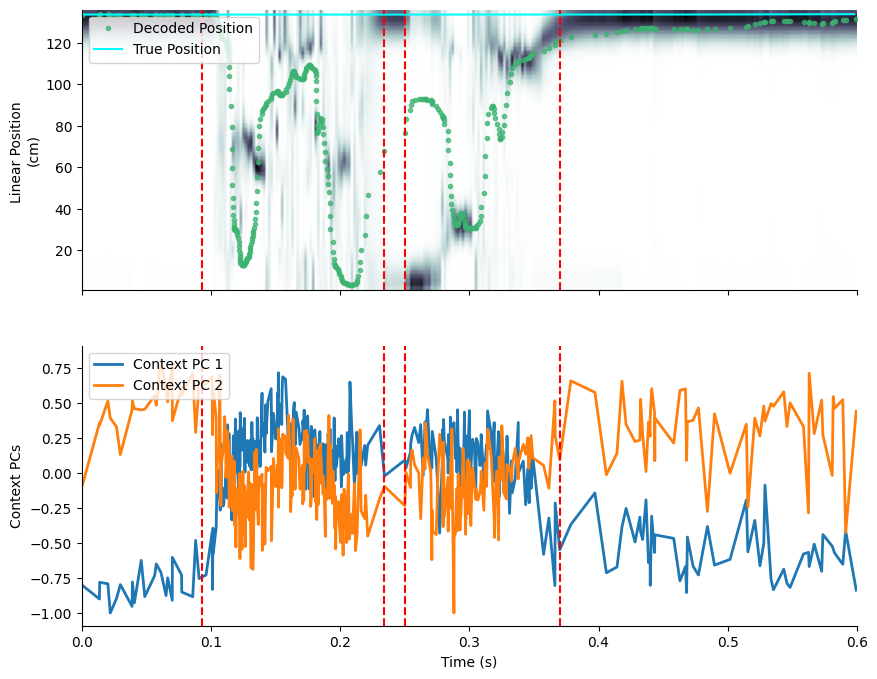

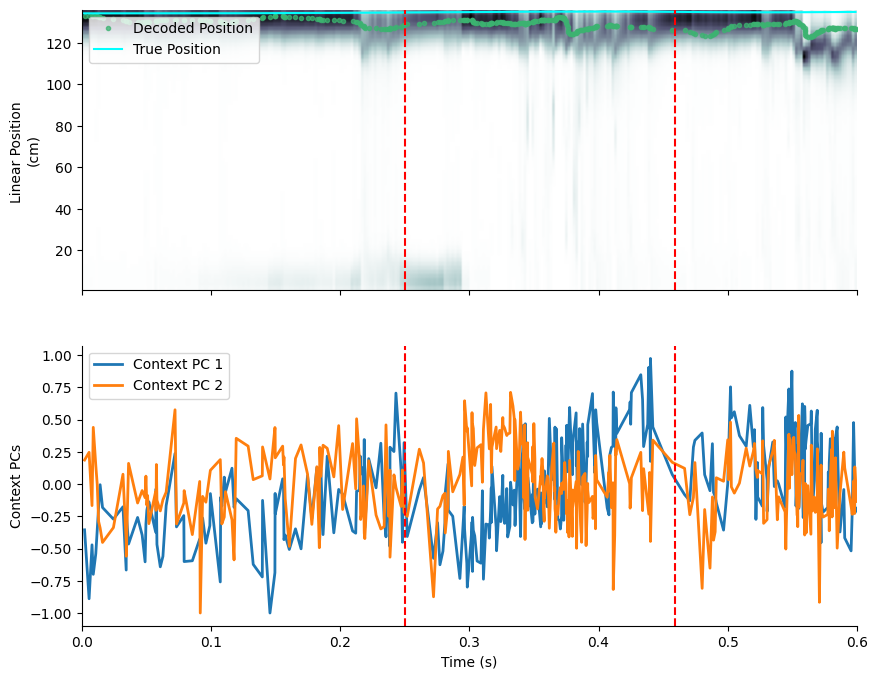

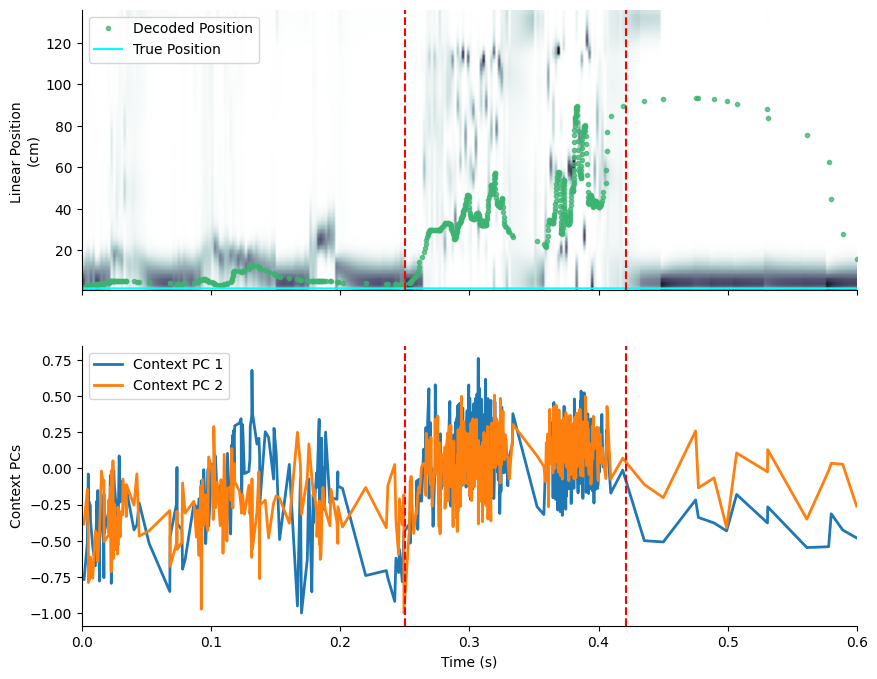

In [ ]:
for i in range(30):
    interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
    interval = interval[i]
    ripple_interval_i = interval.copy()
    st = interval[0] + t_rng[0]
    en = interval[0] + t_rng[1]

    # pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
    # t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
    ind_pred = np.logical_and(t_pred >= st, t_pred <= en)
    pos_pred = feature_pred[ind_pred]

    fig, ax = plt.subplots(
        nrows=2,
        sharex=True,
        height_ratios=[1, 1],
        figsize=(10, 8),
    )

    t_ripple = ripple_band_obj.timestamps
    ind_ripple = np.logical_and(
        t_ripple >= st,
        t_ripple <= en,
    )
    # ax[0].plot(
    #     t_ripple[ind_ripple] - st,
    #     ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
    #     c="k",
    #     lw=2,
    #     zorder=-10,
    #     label="LFP Theta Band",
    # )
    ax[0].plot(
        t_pred[ind_pred] - st,
        pos_pred,
        c="mediumseagreen",
        label="Decoded Position",
        lw=1,
        alpha=0.75,
        marker="o",
        markersize=3,
        linestyle="",
    )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st,
        pos_t <= en,
    )
    ax[0].plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="cyan",
        # s=10,
        label="True Position",
    )

    # ind_context = np.logical_and(
    #     analysis.t_interp >= st,
    #     analysis.t_interp <= en,
    # )
    # c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
    # if len(c_plot.shape) == 1:
    #     c_plot = c_plot[:, None]
    # c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

    ind_context = np.logical_and(
        analysis.t >= st,
        analysis.t <= en,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]

    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        plt.plot(
            analysis.t[ind_context] - st,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=2,
        )

    for a in ax:
        a.spines[["top", "right"]].set_visible(False)

    ax[1].set_xlabel("Time (s)")
    ax[0].set_ylabel("Linear Position \n(cm)")
    ax[1].set_ylabel("Context PCs")
    plt.xlim(0, t_rng[1] - t_rng[0])

    # for t_ in interval:
    #     ax[1].axvline(interval[0] - st, color="red", ls="--")

    for ripple in ripple_intervals:
        # if ripple[0] > st and ripple[1] < en:
        #     for a in ax:
        #         a.axvline(ripple[0] - st, color="r", ls="--")
        #         a.axvline(ripple[1] - st, color="r", ls="--")
        for r in np.ravel(ripple):
            if r >= st and r <= en:
                for a in ax:
                    a.axvline(r - st, color="r", ls="--")

    ind_decode = np.logical_and(
        decode_time >= st,
        decode_time <= en,
    )
    # ax[0].plot(
    #     decode_time[ind_decode] - st,
    #     decode_pos[ind_decode],
    #     c="orange",
    #     label="Eric's Clusterless Decoding",
    # )
    ax[0].imshow(
        posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en - st, results.position.min(), results.position.max()],
        zorder=-10,
    )

    ax[0].legend(loc="upper left")
    ax[1].legend(loc="upper left")

    # fig.savefig(
    #     figure_folder / f"example_ripple_decode_and_model_comparison.svg",
    # )

/tmp/ipykernel_3783385/867632423.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


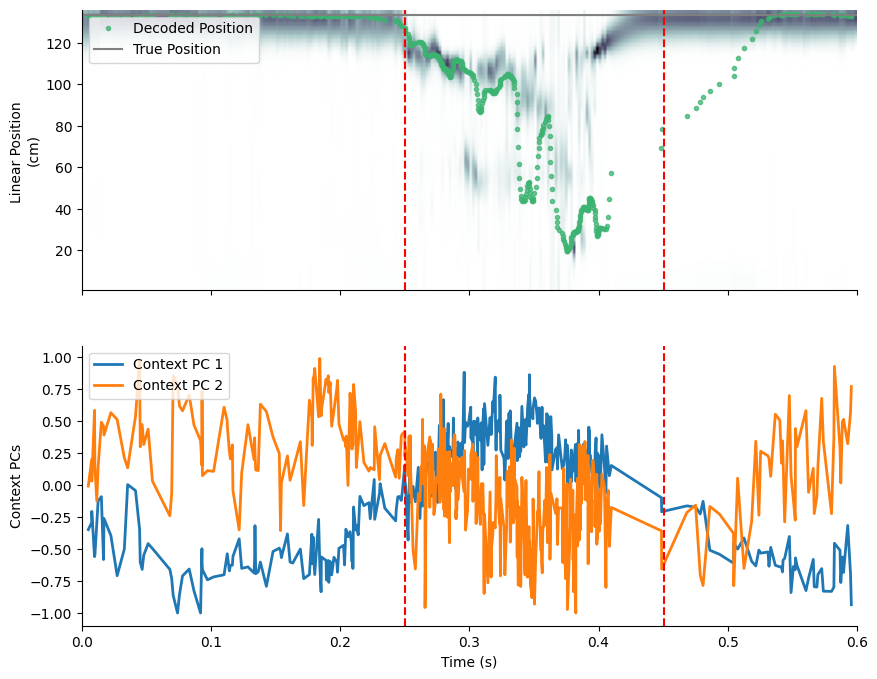

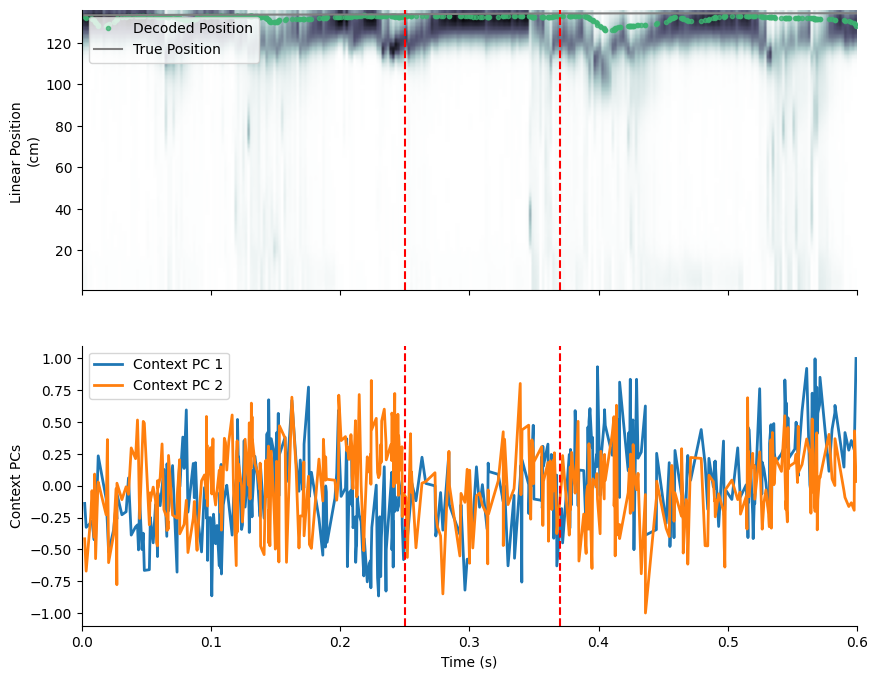

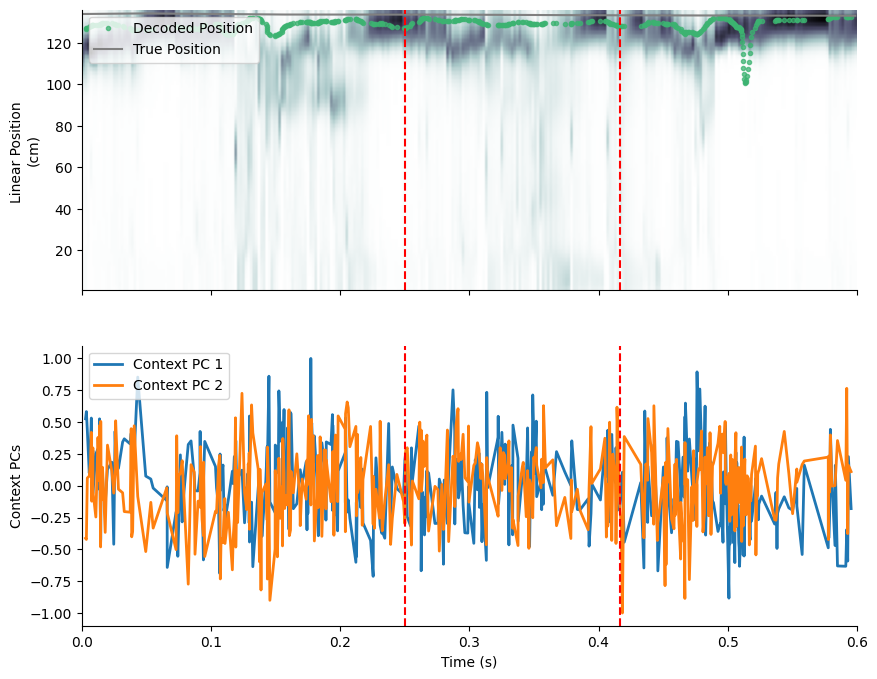

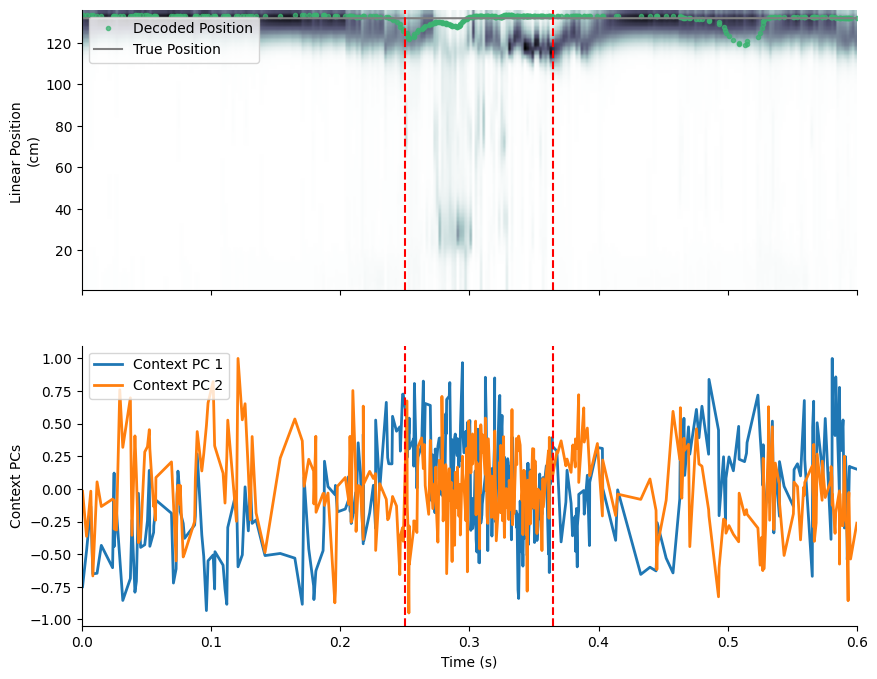

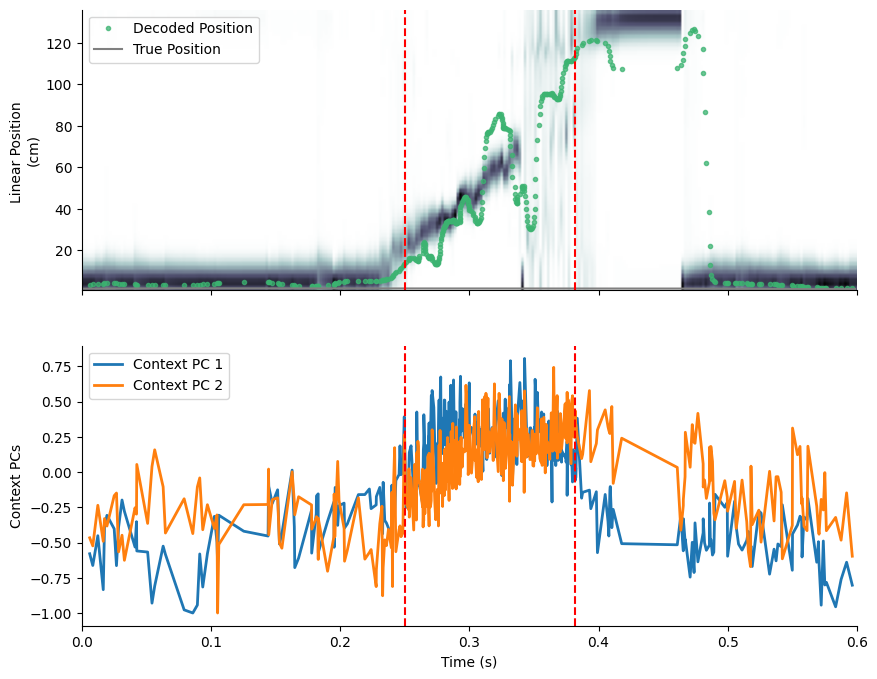

...

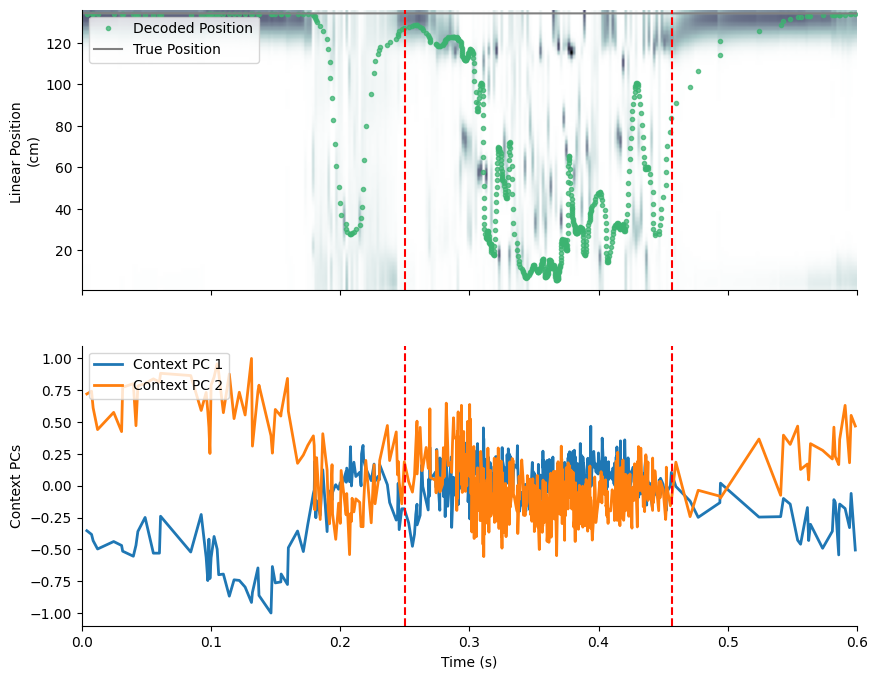

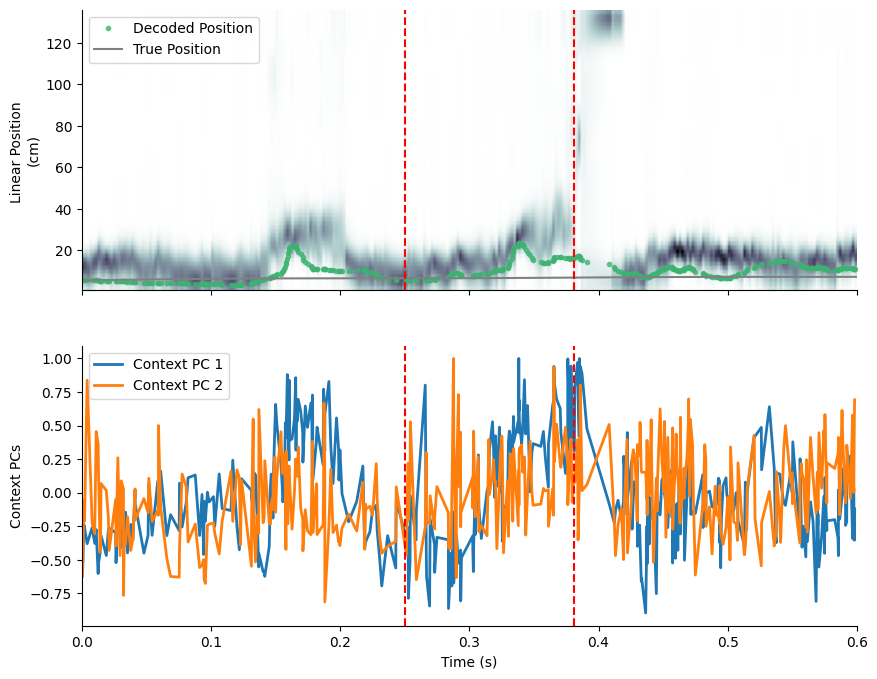

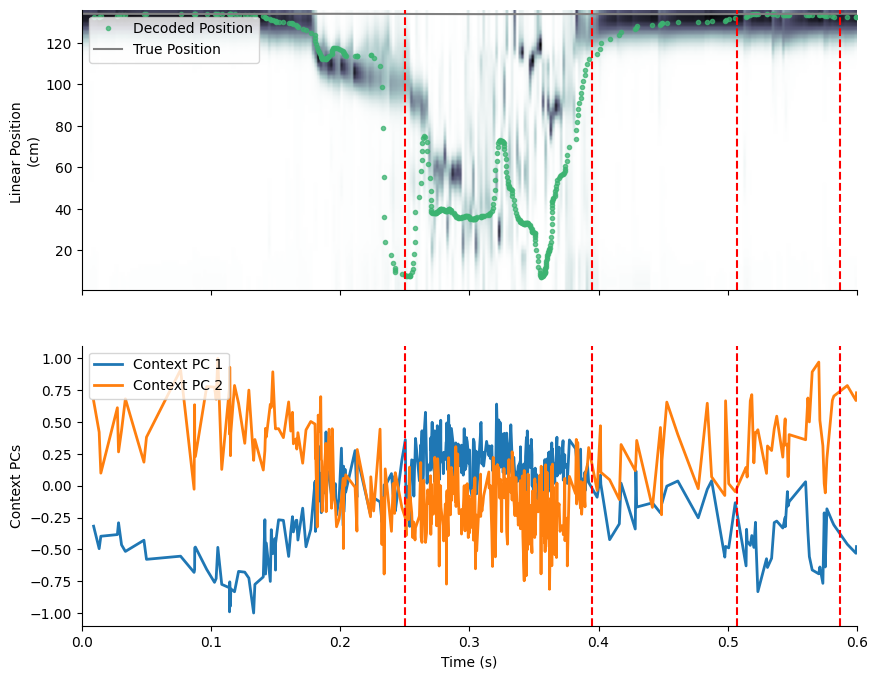

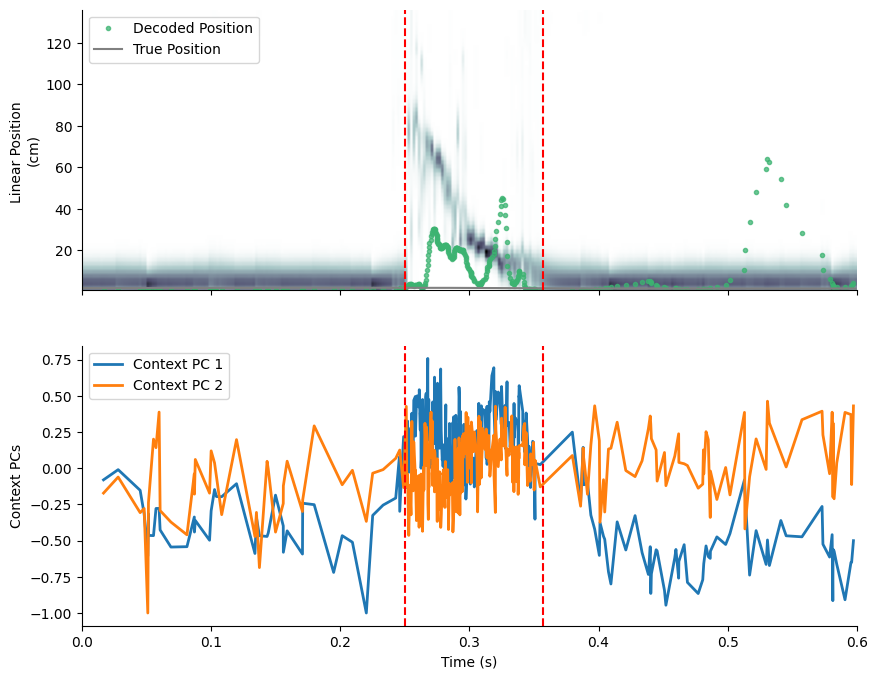

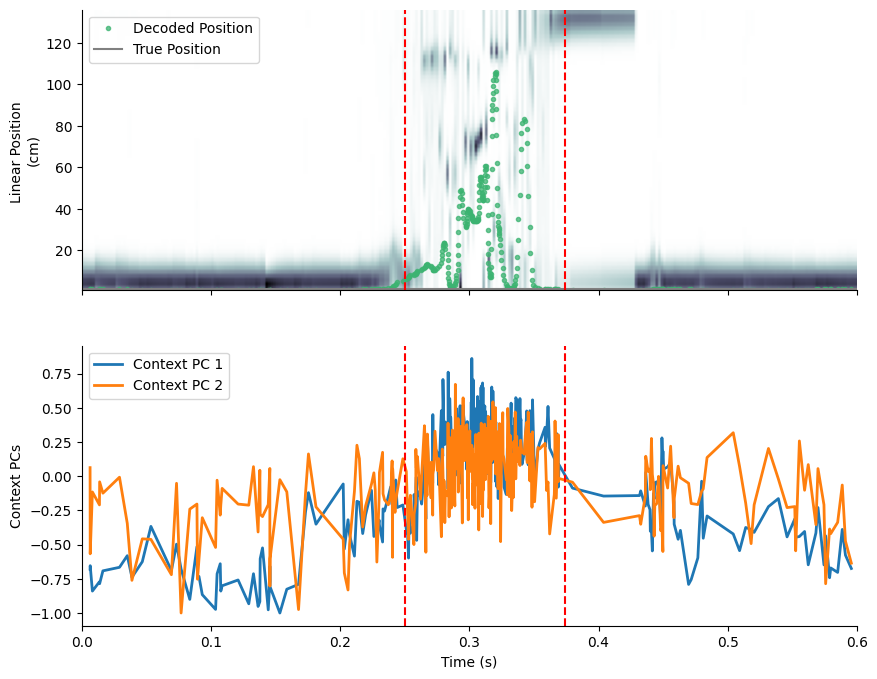

In [ ]:
n_examples = 0
for i in range(300):
    interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
    interval = interval[i]
    ripple_interval_i = interval.copy()
    st = interval[0] + t_rng[0]
    en = interval[0] + t_rng[1]

    st_eric = np.digitize(interval[0], decode_time)
    en_eric = np.digitize(interval[1], decode_time)
    pos_eric = decode_pos[st_eric:en_eric]
    range_eric = np.max(pos_eric) - np.min(pos_eric)
    if range_eric < 20:
        continue

    n_examples += 1
    if n_examples > 50:
        break

    # pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
    # t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
    ind_pred = np.logical_and(t_pred >= st, t_pred <= en)
    pos_pred = feature_pred[ind_pred]

    fig, ax = plt.subplots(
        nrows=2,
        sharex=True,
        height_ratios=[1, 1],
        figsize=(10, 8),
    )

    t_ripple = ripple_band_obj.timestamps
    ind_ripple = np.logical_and(
        t_ripple >= st,
        t_ripple <= en,
    )
    # ax[0].plot(
    #     t_ripple[ind_ripple] - st,
    #     ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
    #     c="k",
    #     lw=2,
    #     zorder=-10,
    #     label="LFP Theta Band",
    # )
    ax[0].plot(
        t_pred[ind_pred] - st,
        pos_pred,
        c="mediumseagreen",
        label="Decoded Position",
        lw=1,
        alpha=0.75,
        marker="o",
        markersize=3,
        linestyle="",
    )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st,
        pos_t <= en,
    )
    ax[0].plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="grey",
        # s=10,
        label="True Position",
    )

    # ind_context = np.logical_and(
    #     analysis.t_interp >= st,
    #     analysis.t_interp <= en,
    # )
    # c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
    # if len(c_plot.shape) == 1:
    #     c_plot = c_plot[:, None]
    # c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

    ind_context = np.logical_and(
        analysis.t >= st,
        analysis.t <= en,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]

    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        plt.plot(
            analysis.t[ind_context] - st,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=2,
        )

    for a in ax:
        a.spines[["top", "right"]].set_visible(False)

    ax[1].set_xlabel("Time (s)")
    ax[0].set_ylabel("Linear Position \n(cm)")
    ax[1].set_ylabel("Context PCs")
    plt.xlim(0, t_rng[1] - t_rng[0])

    # for t_ in interval:
    #     ax[1].axvline(interval[0] - st, color="red", ls="--")

    for ripple in ripple_intervals:
        # if ripple[0] > st and ripple[1] < en:
        #     for a in ax:
        #         a.axvline(ripple[0] - st, color="r", ls="--")
        #         a.axvline(ripple[1] - st, color="r", ls="--")
        for r in np.ravel(ripple):
            if r >= st and r <= en:
                for a in ax:
                    a.axvline(r - st, color="r", ls="--")

    ind_decode = np.logical_and(
        decode_time >= st,
        decode_time <= en,
    )
    # ax[0].plot(
    #     decode_time[ind_decode] - st,
    #     decode_pos[ind_decode],
    #     c="orange",
    #     label="Eric's Clusterless Decoding",
    # )
    ax[0].imshow(
        posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en - st, results.position.min(), results.position.max()],
        zorder=-10,
    )

    ax[0].legend(loc="upper left")
    ax[1].legend(loc="upper left")

    # fig.savefig(
    #     figure_folder / f"example_ripple_decode_and_model_comparison.svg",
    # )